In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("..")

from src.utils.eda import (
    dataset_overview,
    missing_report,
    plot_missing_top,
    plot_value_counts,
    plot_numeric_distribution,
    train_vs_holdout,
)

In [2]:
BASE_DIR = Path("../data")

device_catalog = pd.read_csv(BASE_DIR / "device_catalog.csv")
device_sessions = pd.read_csv(BASE_DIR / "device_sessions.csv")
dts_holdout = pd.read_csv(BASE_DIR / "dts_holdout.csv")
dts_train = pd.read_csv(BASE_DIR / "dts_train.csv")
kyc_records = pd.read_csv(BASE_DIR / "kyc_records.csv")
sim_events = pd.read_csv(BASE_DIR / "sim_events.csv")

## Overview

In [3]:
datasets = {
    "dts_train": dts_train,
    "dts_holdout": dts_holdout,
    "sim_events": sim_events,
    "device_sessions": device_sessions,
    "kyc_records": kyc_records,
    "device_catalog": device_catalog,
}

dataset_overview(datasets)

,table,rows,columns,duplicated_rows
0,dts_train,51047,60,0
1,dts_holdout,20000,57,0
2,sim_events,101755,4,0
3,device_sessions,1276727,9,710
4,kyc_records,71047,5,0
5,device_catalog,18,6,0


## Data checks

### Missing values

dts_train


,missing_count,missing_pct,dtype,nunique
AgeHH1,909,1.780712,float64,43
AgeHH2,909,1.780712,float64,43
PercChangeMinutes,367,0.718945,float64,2262
PercChangeRevenues,367,0.718945,float64,2899
MonthlyRevenue,156,0.305601,float64,12665
MonthlyMinutes,156,0.305601,float64,2719
TotalRecurringCharge,156,0.305601,float64,214
DirectorAssistedCalls,156,0.305601,float64,146
OverageMinutes,156,0.305601,float64,746
RoamingCalls,156,0.305601,float64,530


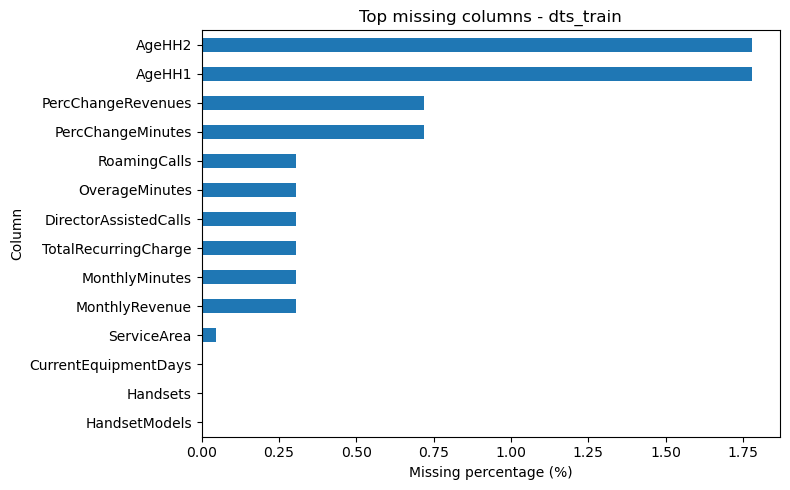

dts_holdout


,missing_count,missing_pct,dtype,nunique
AgeHH2,335,1.675,float64,43
AgeHH1,335,1.675,float64,42
PercChangeMinutes,135,0.675,float64,1688
PercChangeRevenues,135,0.675,float64,2130
MonthlyMinutes,60,0.300,float64,2216
TotalRecurringCharge,60,0.300,float64,182
DirectorAssistedCalls,60,0.300,float64,112
OverageMinutes,60,0.300,float64,566
RoamingCalls,60,0.300,float64,366
MonthlyRevenue,60,0.300,float64,8383


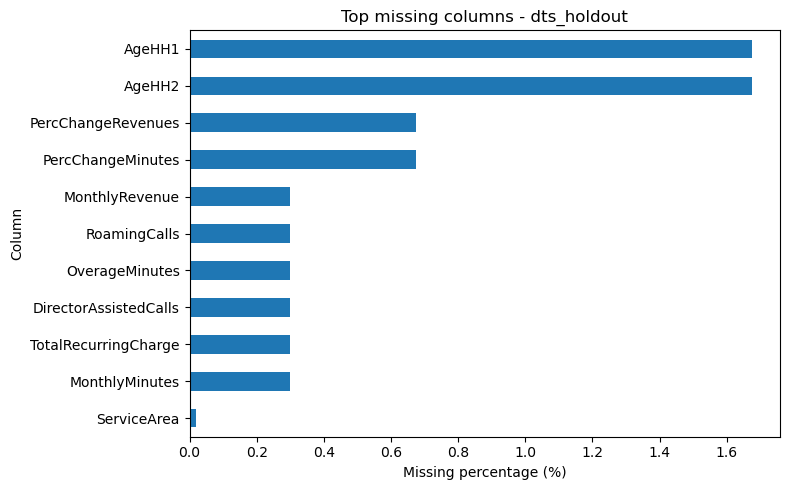

sim_events


,missing_count,missing_pct,dtype,nunique


No missing values in sim_events
device_sessions


,missing_count,missing_pct,dtype,nunique


No missing values in device_sessions
kyc_records


,missing_count,missing_pct,dtype,nunique
FaceMatchScore,32680,45.997720,float64,420
IDDocMatchScore,7105,10.000422,float64,558


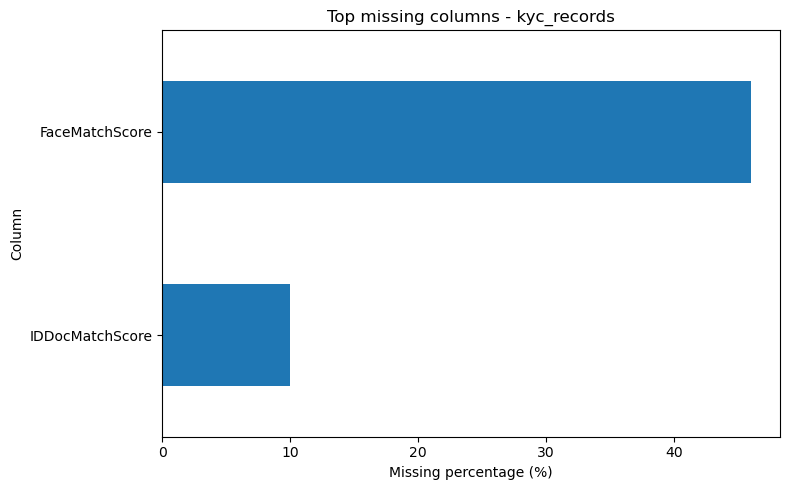

device_catalog


,missing_count,missing_pct,dtype,nunique


No missing values in device_catalog


In [4]:
for name, df in datasets.items():
    print('=' * 80)
    print(name)
    
    report = missing_report(df)
    
    display(
        report.query("missing_pct > 0")
        .head(20)
    )
    
    plot_missing_top(df, name)
    plt.show()

### Duplicated records

In [5]:
for name, df in datasets.items():
    print(
        f"{name}: {df.duplicated().sum()} duplicated rows"
    )

dts_train: 0 duplicated rows
dts_holdout: 0 duplicated rows
sim_events: 0 duplicated rows
device_sessions: 710 duplicated rows
kyc_records: 0 duplicated rows
device_catalog: 0 duplicated rows


In [6]:
710 / len(device_sessions)

0.0005561094893426707

Device sessions có 710 duplicated rows. (~0.06%), có thể do khác nhau đến phút, giây nhưng chỉ ghi nhận đến mức giờ

### Datatype checks

In [7]:
for name, df in datasets.items():
    print(name)
    print(df.dtypes)

dts_train
CustomerID                     int64
Churn                         object
MonthlyRevenue               float64
MonthlyMinutes               float64
TotalRecurringCharge         float64
DirectorAssistedCalls        float64
OverageMinutes               float64
RoamingCalls                 float64
PercChangeMinutes            float64
PercChangeRevenues           float64
DroppedCalls                 float64
BlockedCalls                 float64
UnansweredCalls              float64
CustomerCareCalls            float64
ThreewayCalls                float64
ReceivedCalls                float64
OutboundCalls                float64
InboundCalls                 float64
PeakCallsInOut               float64
OffPeakCallsInOut            float64
DroppedBlockedCalls          float64
CallForwardingCalls          float64
CallWaitingCalls             float64
MonthsInService                int64
UniqueSubs                     int64
ActiveSubs                     int64
ServiceArea                 

## Feature Distribution

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def long_tail_summary(df, cols):
    rows = []

    for col in cols:
        s = pd.to_numeric(df[col], errors="coerce").dropna()

        rows.append({
            "feature": col,
            "count": len(s),
            "missing_pct": df[col].isna().mean() * 100,
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "min": s.min(),
            "p75": s.quantile(0.75),
            "p90": s.quantile(0.90),
            "p95": s.quantile(0.95),
            "p99": s.quantile(0.99),
            "max": s.max(),
            "max_p95_ratio": s.max() / s.quantile(0.95) if s.quantile(0.95) != 0 else np.nan,
            "p99_p50_ratio": s.quantile(0.99) / s.median() if s.median() != 0 else np.nan,
            "skew": s.skew()
        })

    return (
        pd.DataFrame(rows)
        .sort_values("skew", ascending=False)
        .reset_index(drop=True)
    )
    
long_tail_cols = [
    "MonthlyRevenue",
    "MonthlyMinutes",
    "TotalRecurringCharge",
    "DirectorAssistedCalls",
    "OverageMinutes",
    "RoamingCalls",
    "DroppedCalls",
    "BlockedCalls",
    "UnansweredCalls",
    "CustomerCareCalls",
    "ReceivedCalls",
    "OutboundCalls",
    "InboundCalls",
    "PeakCallsInOut",
    "OffPeakCallsInOut",
    "DroppedBlockedCalls",
    "CallForwardingCalls",
    "CallWaitingCalls",
    "MonthsInService",
    "Handsets",
    "HandsetModels",
    "CurrentEquipmentDays",
    "RetentionCalls",
    "ReferralsMadeBySubscriber",
    "AdjustmentsToCreditRating"
]

long_tail_report = long_tail_summary(dts_train, long_tail_cols)
long_tail_report

,feature,count,missing_pct,mean,median,std,min,p75,p90,p95,p99,max,max_p95_ratio,p99_p50_ratio,skew
0,CallForwardingCalls,51047,0.000000,0.012277,0.00,0.594168,0.00,0.000,0.00,0.00,0.000,81.30,NaN,NaN,91.634791
1,RoamingCalls,50891,0.305601,1.236244,0.00,9.818294,0.00,0.300,2.10,5.10,21.500,1112.40,218.117647,NaN,57.881773
2,ReferralsMadeBySubscriber,51047,0.000000,0.052070,0.00,0.307592,0.00,0.000,0.00,0.00,1.000,35.00,NaN,NaN,36.739725
3,AdjustmentsToCreditRating,51047,0.000000,0.053911,0.00,0.383147,0.00,0.000,0.00,0.00,1.000,25.00,NaN,NaN,18.623149
4,CustomerCareCalls,51047,0.000000,1.868999,0.00,5.096138,0.00,1.700,5.30,9.30,21.000,327.30,35.193548,NaN,14.235913
5,DirectorAssistedCalls,50891,0.305601,0.895229,0.25,2.228546,0.00,0.990,2.48,4.21,9.650,159.39,37.859857,38.600000,13.567882
6,CallWaitingCalls,51047,0.000000,1.840504,0.30,5.585129,0.00,1.300,4.70,8.70,23.000,212.70,24.448276,76.666667,11.121429
7,BlockedCalls,51047,0.000000,4.085672,1.00,10.946905,0.00,3.700,10.00,17.00,47.000,384.30,22.605882,47.000000,9.790454
8,OverageMinutes,50891,0.305601,40.027785,3.00,96.588076,0.00,41.000,115.00,190.00,429.100,4321.00,22.742105,143.033333,8.113911
9,RetentionCalls,51047,0.000000,0.037201,0.00,0.206483,0.00,0.000,0.00,0.00,1.000,4.00,NaN,NaN,6.296663


In [63]:
for col in long_tail_cols:
    s = pd.to_numeric(
        dts_train[col],
        errors="coerce"
    )

    if (s <= -1).any():
        print(
            col,
            "has values <= -1"
        )

MonthlyRevenue has values <= -1
TotalRecurringCharge has values <= -1
CurrentEquipmentDays has values <= -1


In [65]:
for col in [
    "MonthlyRevenue",
    "TotalRecurringCharge",
    "CurrentEquipmentDays"
]:
    print("=" * 50)
    print(col)

    print(
        dts_train.loc[
            dts_train[col] < 0,
            col
        ].value_counts().sort_index()
    )

MonthlyRevenue
MonthlyRevenue
-6.17    1
-5.86    1
-2.52    1
Name: count, dtype: int64
TotalRecurringCharge
TotalRecurringCharge
-11.0    1
-9.0     1
-6.0     2
-5.0     1
-2.0     2
-1.0     1
Name: count, dtype: int64
CurrentEquipmentDays
CurrentEquipmentDays
-5.0     3
-4.0     6
-3.0    26
-2.0    23
-1.0    18
Name: count, dtype: int64


In [66]:
neg_revenue = dts_train[
    dts_train["MonthlyRevenue"] < 0
]

neg_revenue[
    [
        "CustomerID",
        "MonthlyRevenue",
        "FraudFlag",
        "FraudType"
    ]
]

,CustomerID,MonthlyRevenue,FraudFlag,FraudType
26596,3210322,-2.52,0,none
33352,3265738,-5.86,0,none
48038,3378298,-6.17,0,none


In [67]:
neg_charge = dts_train[
    dts_train["TotalRecurringCharge"] < 0
]

neg_charge[
    [
        "CustomerID",
        "TotalRecurringCharge",
        "FraudFlag",
        "FraudType"
    ]
]

,CustomerID,TotalRecurringCharge,FraudFlag,FraudType
3605,3028134,-2.0,0,none
18432,3144294,-2.0,0,none
23904,3188158,-6.0,0,none
30764,3244958,-9.0,0,none
33352,3265738,-5.0,0,none
35304,3281886,-1.0,0,none
42186,3335626,-11.0,0,none
48038,3378298,-6.0,0,none


In [68]:
neg_equipment = dts_train[
    dts_train["CurrentEquipmentDays"] < 0
]

neg_equipment[
    [
        "CustomerID",
        "CurrentEquipmentDays",
        "FraudFlag",
        "FraudType"
    ]
]

,CustomerID,CurrentEquipmentDays,FraudFlag,FraudType
107,3000762,-3.0,0,none
424,3003242,-1.0,0,none
2107,3016538,-3.0,0,none
2145,3016766,-1.0,0,none
3883,3030326,-3.0,0,none
...,...,...,...,...
48923,3384342,-3.0,0,none
49160,3385954,-3.0,0,none
49441,3387894,-2.0,0,none
49530,3388482,-1.0,0,none


In [54]:
def plot_long_tail(df, col, bins=50):
    s = pd.to_numeric(
        df[col],
        errors="coerce"
    ).dropna()

    fig, axes = plt.subplots(
        1, 2,
        figsize=(12,4)
    )

    axes[0].hist(
        s,
        bins=bins
    )

    axes[0].set_title(
        f"{col} - original"
    )

    positive_s = s[s > -1]

    axes[1].hist(
        np.log1p(positive_s),
        bins=bins
    )

    axes[1].set_title(
        f"{col} - log1p"
    )

    plt.tight_layout()
    plt.show()

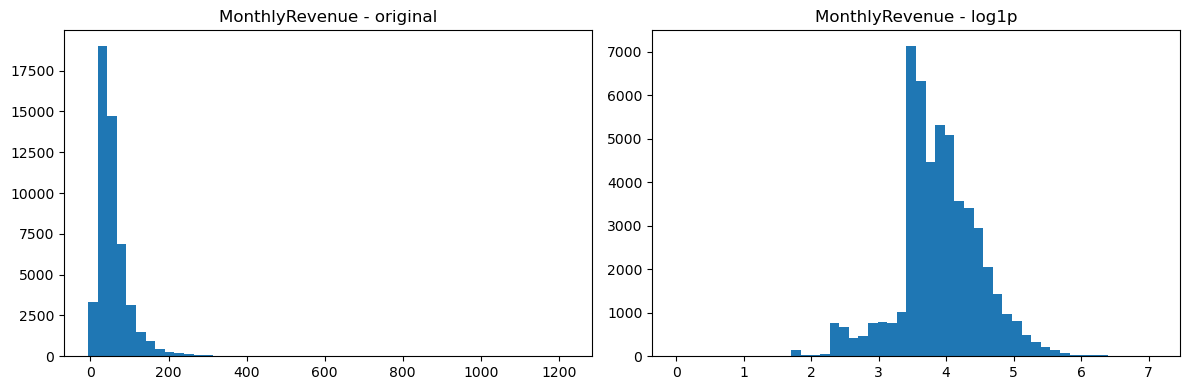

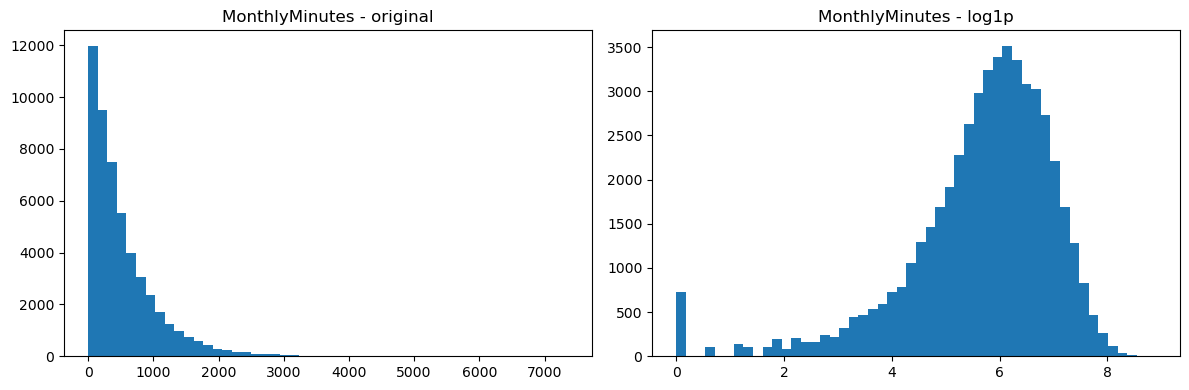

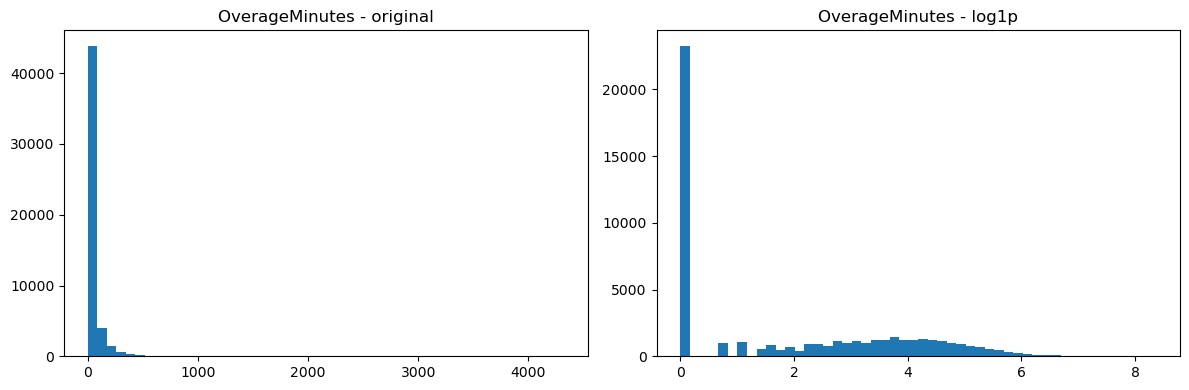

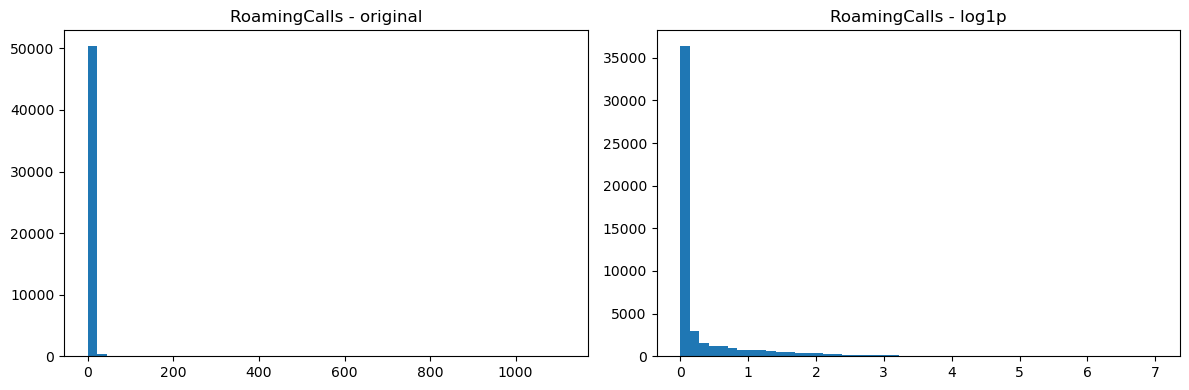

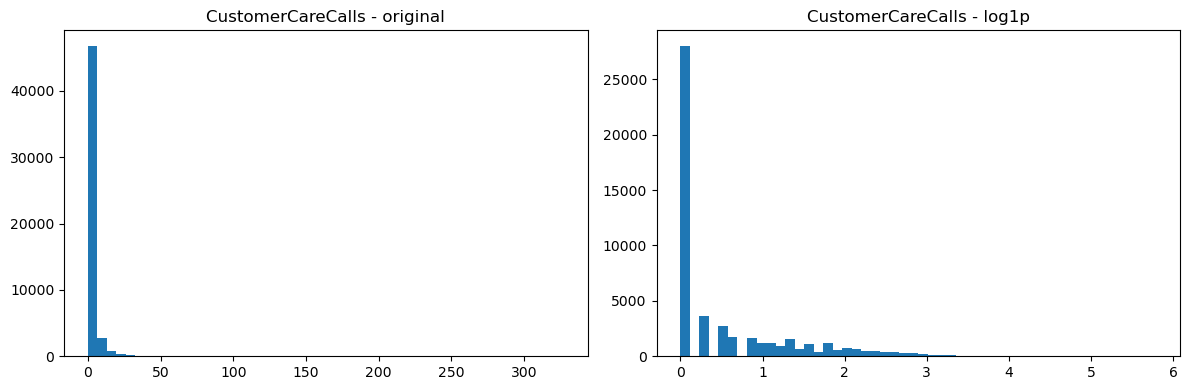

In [71]:
for col in [
    "MonthlyRevenue",
    "MonthlyMinutes",
    "OverageMinutes",
    "RoamingCalls",
    "CustomerCareCalls",
]:
    plot_long_tail(dts_train, col)

,CountryCode,session_count,session_pct
0,US,1246440,97.627762
1,CA,3863,0.302571
2,DE,3819,0.299124
3,JP,3811,0.298498
4,TH,3807,0.298184
5,FR,3797,0.297401
6,MX,3742,0.293093
7,GB,3741,0.293015
8,CN,3707,0.290352


,IPType,session_count,session_pct
0,mobile_carrier,834480,65.360880
1,residential_wifi,411585,32.237510
2,datacenter,18387,1.440167
3,vpn_proxy,12275,0.961443


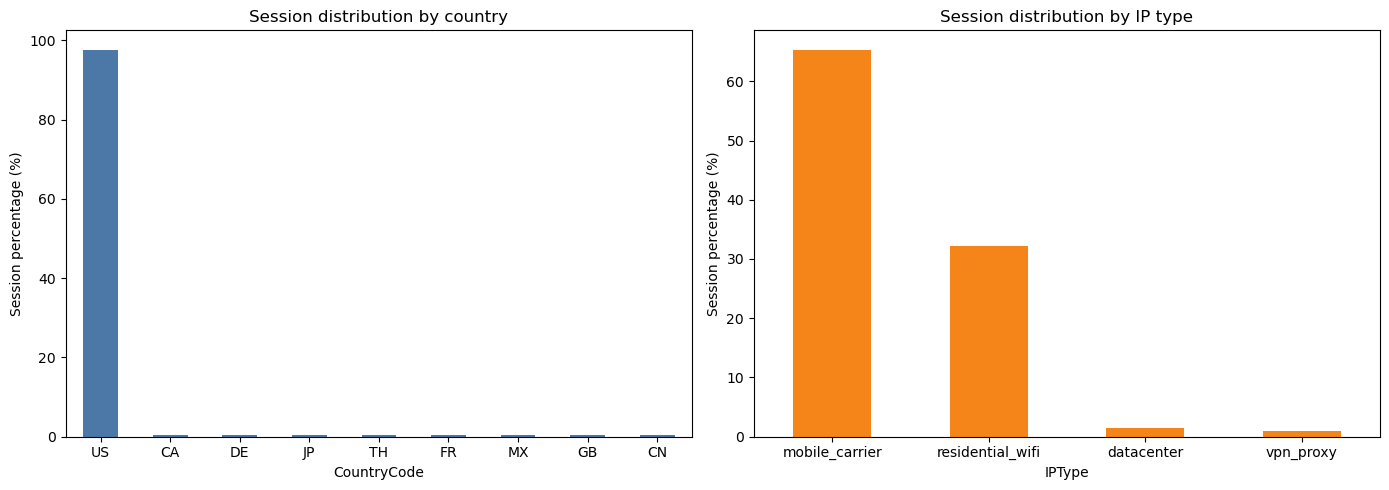

In [88]:
import matplotlib.pyplot as plt
import pandas as pd

def session_distribution_report(df, column):
    report = (
        df[column]
        .value_counts()
        .rename_axis(column)
        .reset_index(name="session_count")
    )
    report["session_pct"] = report["session_count"] / len(df) * 100
    return report

country_report = session_distribution_report(device_sessions, "CountryCode")
iptype_report = session_distribution_report(device_sessions, "IPType")

display(country_report)
display(iptype_report)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

country_report.plot(
    x="CountryCode",
    y="session_pct",
    kind="bar",
    ax=axes[0],
    legend=False,
    color="#4C78A8",
    rot=0
)
axes[0].set_title("Session distribution by country")
axes[0].set_xlabel("CountryCode")
axes[0].set_ylabel("Session percentage (%)")

iptype_report.plot(
    x="IPType",
    y="session_pct",
    kind="bar",
    ax=axes[1],
    legend=False,
    color="#F58518",
    rot=0
)
axes[1].set_title("Session distribution by IP type")
axes[1].set_xlabel("IPType")
axes[1].set_ylabel("Session percentage (%)")

plt.tight_layout()
plt.show()

## Consistency checks

### Activation Date vs MonthsInService

In [8]:
sim_events["EventType"].value_counts()

EventType
number_activation    71047
sim_swap             23509
port_in               7199
Name: count, dtype: int64

In [9]:
activation_date = (
    sim_events[
        sim_events["EventType"] == "number_activation"
    ]
    .groupby("CustomerID")["EventDate"]
    .min()
    .rename("ActivationDate")
    .reset_index()
)

customer_profile = pd.concat(
    [
        dts_train.drop(columns=['FraudFlag', 'FraudType']),
        dts_holdout
    ]
)

customer_profile = customer_profile.merge(
    activation_date,
    on="CustomerID",
    how="left"
)

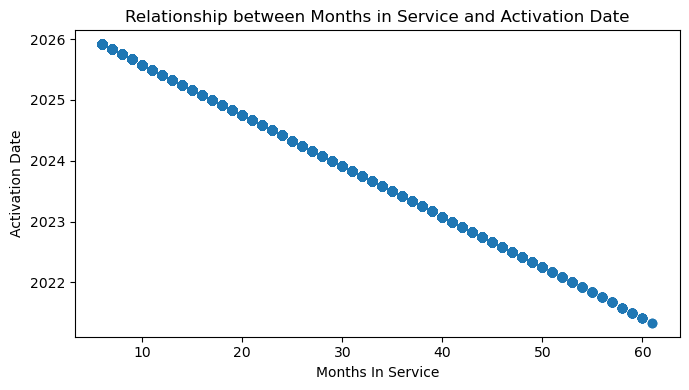

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

customer_profile["ActivationDate"] = pd.to_datetime(
    customer_profile["ActivationDate"]
)

plt.figure(figsize=(7, 4))

plt.scatter(
    customer_profile["MonthsInService"], customer_profile["ActivationDate"]
)

plt.xlabel("Months In Service")
plt.ylabel("Activation Date")
plt.title("Relationship between Months in Service and Activation Date")

plt.tight_layout()
plt.show()

Months in Service càng lớn tương ứng với Activation Date càng từ lâu về trước, điều này là hợp lý

### CurrentEquipmentDays vs FirstSeenIMEI

In [11]:
device_sessions["SessionDate"] = pd.to_datetime(
    device_sessions["SessionDate"]
)

first_seen = (
    device_sessions
    .groupby("CustomerID")["SessionDate"]
    .min()
    .rename("FirstSeenSession")
    .reset_index()
)

last_seen = (
    device_sessions
    .groupby("CustomerID")["SessionDate"]
    .max()
    .rename("LastSeenSession")
    .reset_index()
)

customer_profile = pd.concat(
    [
        dts_train.drop(columns=["FraudFlag", "FraudType"]),
        dts_holdout
    ]
)

customer_profile = customer_profile.merge(
    first_seen,
    on="CustomerID",
    how="left"
)

customer_profile = customer_profile.merge(
    last_seen,
    on="CustomerID",
    how="left"
)

customer_profile["ObservedDeviceDays"] = (
    customer_profile["LastSeenSession"]
    - customer_profile["FirstSeenSession"]
).dt.days

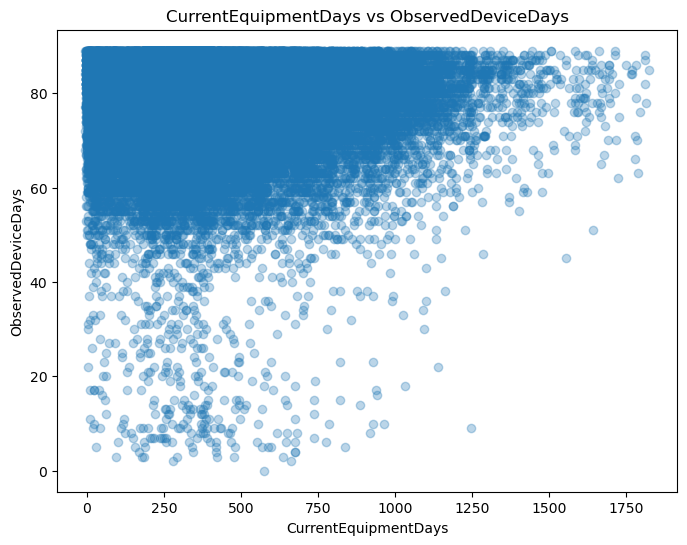

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    customer_profile["CurrentEquipmentDays"],
    customer_profile["ObservedDeviceDays"],
    alpha=0.3
)

plt.xlabel("CurrentEquipmentDays")
plt.ylabel("ObservedDeviceDays")
plt.title(
    "CurrentEquipmentDays vs ObservedDeviceDays"
)

plt.show()

In [13]:
customer_profile[
    ["CurrentEquipmentDays", "ObservedDeviceDays"]
].corr()

,CurrentEquipmentDays,ObservedDeviceDays
CurrentEquipmentDays,1.000000,-0.004584
ObservedDeviceDays,-0.004584,1.000000


Correlation giữa CurrentEquipmentDays và ObservedDeviceDays rất thấp, scatter plot không có xu hướng rõ ràng, điều này cho thấy event log chỉ cover 1 cửa sổ thời gian ngắn (90 ngày gần nhất).

### NewCellphoneUser vs NotNewCellphoneUser

In [14]:
customer_profile[
    [
        "NewCellphoneUser",
        "NotNewCellphoneUser"
    ]
].value_counts()

NewCellphoneUser  NotNewCellphoneUser
No                No                     47479
Yes               No                     13708
No                Yes                     9860
Name: count, dtype: int64

2 biến NewCellphoneUser và NotNewCellphoneUser không đối ngẫu, có thể là chưa xác định, hoặc là do người dùng này có thể là không phải mới mua điện thoại, nhưng cũng chưa dùng đủ lâu để xếp vào ngưỡng NotNew. Có thể gom 2 feature này thành 1 với 3 trạng thái.

## Target checks

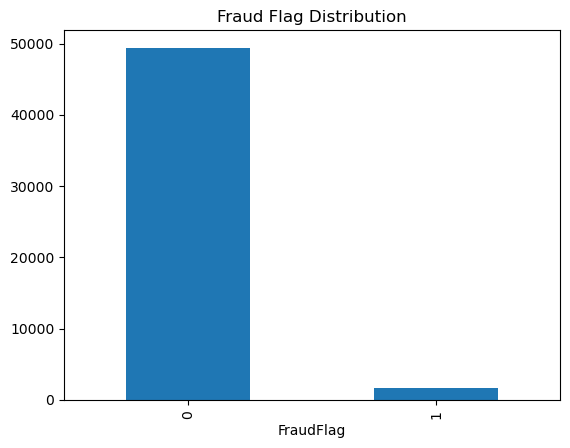

FraudFlag
0    49414
1     1633
Name: count, dtype: int64

In [15]:
fraud_dist = (
    dts_train["FraudFlag"]
    .value_counts()
)

fraud_dist.plot(
    kind="bar"
)

plt.title("Fraud Flag Distribution")
plt.show()

fraud_dist

Fraud chiếm khoảng 3.2%.
Dataset mất cân bằng lớp (class imbalance) đáng kể.

In [16]:
# plot_value_counts(
#     dts_train,
#     "FraudType",
#     normalize=True
# )

dts_train["FraudType"].value_counts()

FraudType
none                  49414
sim_swap_ato            499
mule                    429
device_farm             382
subscription_fraud      323
Name: count, dtype: int64

## Shared IMEI

In [17]:
imei_customer_count = (
    device_sessions
    .groupby("IMEI")["CustomerID"]
    .nunique()
    .rename("CustomerCount")
)

imei_customer_count.describe()

count    74536.000000
mean         1.031247
std          0.257398
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: CustomerCount, dtype: float64

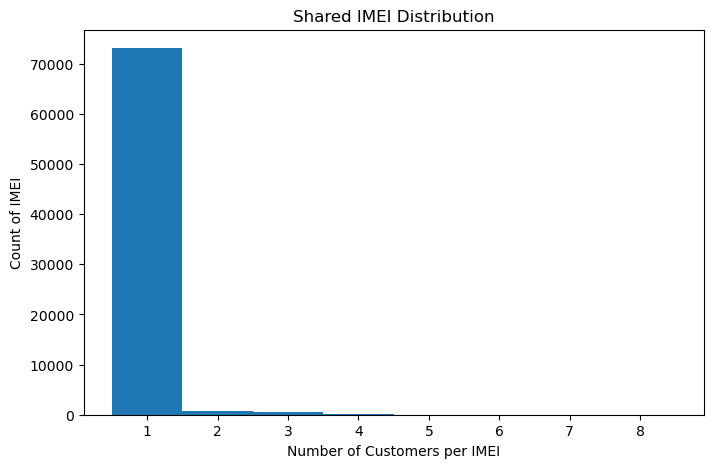

In [18]:
plt.figure(figsize=(8,5))

plt.hist(
    imei_customer_count,
    bins=range(
        1,
        int(imei_customer_count.max()) + 2
    ),
    align="left"
)

plt.xlabel("Number of Customers per IMEI")
plt.ylabel("Count of IMEI")
plt.title("Shared IMEI Distribution")

plt.show()

In [19]:
shared_ratio = (
    (imei_customer_count > 1)
    .mean()
)

print(
    f"Shared IMEI ratio: {shared_ratio:.2%}"
)

Shared IMEI ratio: 1.89%


In [20]:
(
    imei_customer_count
    .value_counts()
    .sort_index()
    .rename_axis("CustomersPerIMEI")
    .reset_index(name="IMEICount")
)

,CustomersPerIMEI,IMEICount
0,1,73124
1,2,703
2,3,609
3,4,56
4,5,13
5,6,9
6,7,11
7,8,11


In [21]:
top_shared_imei = (
    imei_customer_count
    .sort_values(ascending=False)
    .head(20)
)

top_shared_imei

IMEI
354209113932270    8
4400106039694      8
354049065643818    8
350011002921339    8
359999015275035    8
359999010880565    8
350011005756997    8
354209110955290    8
359999010595874    8
352011057403512    8
354049064431512    8
867233030896988    7
352908017423920    7
4400105962607      7
4400101917720      7
354209117722321    7
354209115826405    7
358843034794017    7
867233034371566    7
354049067735315    7
Name: CustomerCount, dtype: int64

In [22]:
shared_imeis = (
    imei_customer_count[
        imei_customer_count > 1
    ].index
)

shared_customers = (
    device_sessions[
        device_sessions["IMEI"]
        .isin(shared_imeis)
    ]["CustomerID"]
    .nunique()
)

shared_customers

3738

Có 3738 khách hàng ĐANG dùng shared IMEI

In [23]:
imei_customer_count = (
    imei_customer_count
    .reset_index()
)

device_sessions_shared = (
    device_sessions
    .merge(
        imei_customer_count,
        on="IMEI",
        how="left"
    )
)

customer_shared = (
    device_sessions_shared
    .groupby("CustomerID")
    ["CustomerCount"]
    .max()
    .rename("MaxCustomersPerIMEI")
    .reset_index()
)

fraud_df = (
    dts_train
    .merge(
        customer_shared,
        on="CustomerID",
        how="left"
    )
)

fraud_df.groupby(
    "MaxCustomersPerIMEI"
)["FraudFlag"].mean()

MaxCustomersPerIMEI
1    0.022520
2    0.076923
3    0.084962
4    0.966443
5    1.000000
6    1.000000
7    1.000000
8    1.000000
Name: FraudFlag, dtype: float64

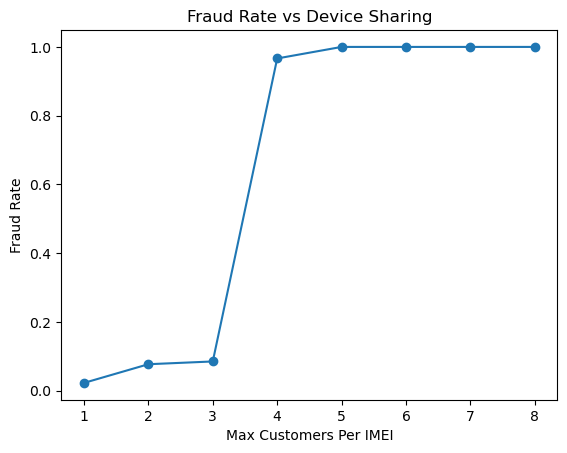

In [24]:
fraud_df.groupby(
    "MaxCustomersPerIMEI"
)["FraudFlag"].mean().plot(
    marker="o"
)

plt.ylabel("Fraud Rate")
plt.xlabel("Max Customers Per IMEI")
plt.title("Fraud Rate vs Device Sharing")

plt.show()

## SIM

In [90]:
iccid_per_customer = (
    sim_events
    .groupby("CustomerID")["ICCID"]
    .nunique()
)

customer_per_iccid = (
    sim_events
    .groupby("ICCID")["CustomerID"]
    .nunique()
)

iccid_distribution = (
    iccid_per_customer
    .value_counts()
    .sort_index()
    .rename_axis("ICCIDCountPerCustomer")
    .reset_index(name="CustomerCount")
)

customer_distribution = (
    customer_per_iccid
    .value_counts()
    .sort_index()
    .rename_axis("CustomerCountPerICCID")
    .reset_index(name="ICCIDCount")
)

display(iccid_distribution)
display(customer_distribution)

,ICCIDCountPerCustomer,CustomerCount
0,1,50648
1,2,17679
2,3,2349
3,4,353
4,5,17
5,6,1


,CustomerCountPerICCID,ICCIDCount
0,1,94556


## PhoneNumberAgeDays

In [72]:
sim_events["EventType"].value_counts()

EventType
number_activation    71047
sim_swap             23509
port_in               7199
Name: count, dtype: int64

In [73]:
sim_events["EventDate"] = pd.to_datetime(
    sim_events["EventDate"]
)

device_sessions["SessionDate"] = pd.to_datetime(
    device_sessions["SessionDate"]
)

In [75]:
reference_date = max(
    sim_events["EventDate"].max(),
    device_sessions["SessionDate"].max()
)

activation_date = (
    sim_events[
        sim_events["EventType"] == "number_activation"
    ]
    .groupby("CustomerID")["EventDate"]
    .min()
    .rename("ActivationDate")
    .reset_index()
)

activation_date["PhoneNumberAgeDays"] = (
    reference_date
    - activation_date["ActivationDate"]
).dt.days

train_phone = dts_train.merge(
    activation_date,
    on="CustomerID",
    how="left"
)

In [76]:
train_phone["PhoneNumberAgeDays"].describe()

count    51047.000000
mean       569.778067
std        297.948622
min        182.000000
25%        334.000000
50%        486.000000
75%        729.000000
max       1854.000000
Name: PhoneNumberAgeDays, dtype: float64

In [84]:
train_phone.groupby(
    "FraudFlag"
)["PhoneNumberAgeDays"].describe()

,count,mean,std,min,25%,50%,75%,max
FraudFlag,,,,,,,,
0,49414.0,570.189035,298.398457,182.0,334.0,486.0,729.0,1854.0
1,1633.0,557.342315,283.805777,182.0,334.0,486.0,699.0,1732.0


In [85]:
import numpy as np

bins = [-1, 7, 30, 90, 180, 365, np.inf]

labels = [
    "<=7d",
    "8-30d",
    "31-90d",
    "91-180d",
    "181-365d",
    ">365d"
]

train_phone["PhoneAgeBucket"] = pd.cut(
    train_phone["PhoneNumberAgeDays"],
    bins=bins,
    labels=labels
)

In [86]:
phone_age_analysis = (
    train_phone
    .groupby("PhoneAgeBucket", observed=True)
    .agg(
        customer_count=("CustomerID", "count"),
        fraud_count=("FraudFlag", "sum"),
        fraud_rate=("FraudFlag", "mean")
    )
    .reset_index()
)

phone_age_analysis

,PhoneAgeBucket,customer_count,fraud_count,fraud_rate
0,181-365d,16975,548,0.032283
1,>365d,34072,1085,0.031844


## Train vs Holdout comparison

In [25]:
print(
    len(dts_train),
    len(dts_holdout)
)

51047 20000


Count:


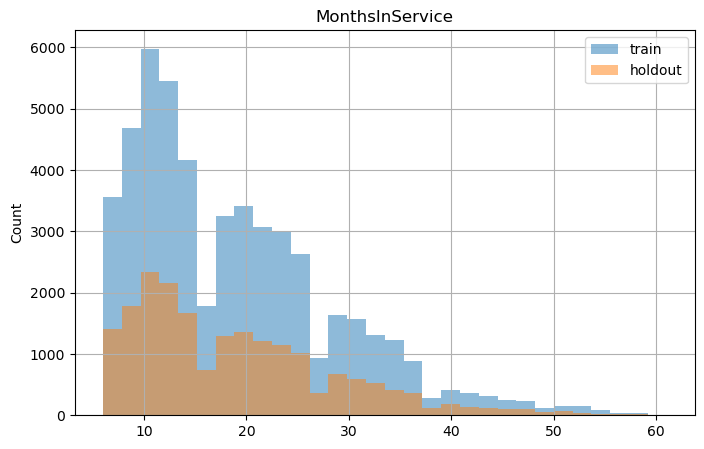

Density:


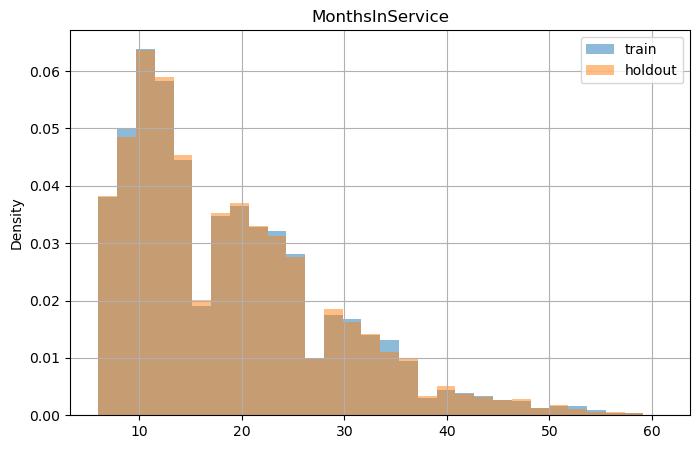

Boxplot:


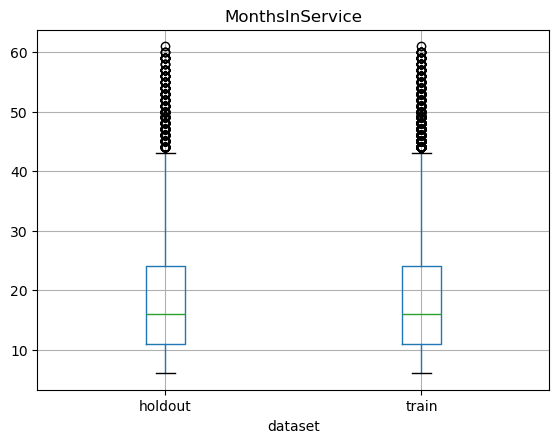

Descriptive Statistic:
       MonthsInService  MonthsInService
count     51047.000000     20000.000000
mean         18.756264        18.736950
std           9.800138         9.755645
min           6.000000         6.000000
25%          11.000000        11.000000
50%          16.000000        16.000000
75%          24.000000        24.000000
max          61.000000        61.000000
KS test:
KstestResult(statistic=np.float64(0.003935551550531824), pvalue=np.float64(0.9785791324554773), statistic_location=np.int64(21), statistic_sign=np.int8(-1))


In [31]:
train_vs_holdout(dts_train, dts_holdout, "MonthsInService")

In [41]:
dts_train['HandsetPrice'].dtype

dtype('O')

In [50]:
import pandas as pd
from scipy.stats import ks_2samp

numeric_cols = [
    "MonthlyRevenue",
    "MonthlyMinutes",
    "CurrentEquipmentDays",
    "Handsets",
    "HandsetPrice",
]

ks_results = []

for col in numeric_cols:
    train_clean = dts_train[col].dropna()
    holdout_clean = dts_holdout[col].dropna()
    
    if train_clean.empty or holdout_clean.empty:
        print(f"Cột {col} bị rỗng sau khi loại bỏ NaN!")
        continue
        
    res = ks_2samp(train_clean, holdout_clean)

    status = (
        "Drift detected (Khác biệt)"
        if res.pvalue < 0.05
        else "Không đủ cơ sở để bác bỏ giả thuyết tương đồng"
    )

    ks_results.append(
        {
            "Feature": col,
            "KS Statistic (D)": f"{res.statistic:.5f}",
            "P-Value": f"{res.pvalue:.4f}",  
            "Status": status,
        }
    )

df_res = pd.DataFrame(ks_results)
display(df_res) 

,Feature,KS Statistic (D),P-Value,Status
0,MonthlyRevenue,0.00419,0.9624,Không đủ cơ sở để bác bỏ giả thuyết tương đồng
1,MonthlyMinutes,0.00684,0.5126,Không đủ cơ sở để bác bỏ giả thuyết tương đồng
2,CurrentEquipmentDays,0.00824,0.2812,Không đủ cơ sở để bác bỏ giả thuyết tương đồng
3,Handsets,0.00472,0.9051,Không đủ cơ sở để bác bỏ giả thuyết tương đồng
4,HandsetPrice,0.00454,0.9268,Không đủ cơ sở để bác bỏ giả thuyết tương đồng


Train và holdout có phân phối tương đồng đáng kể về MonthsInService, MonthlyRevenue, MonthlyMinutes, CurrentEquipmentDays, Handsets, HandsetPrice.